# Tier 3 compatibility margin verification

Tier 3 expresses powertrain feasibility as named, normalized margins instead of
hand-written inequality lists:

* **Operating margins** compare each instance's port values with its own limits
  (power, torque, speed, voltage window, battery charge/discharge power).
* **Design margins** compare adjacent ratings across shaft connections and the
  electrical bus, using component parameters only.

A margin is $(\text{limit} - \text{value}) / \text{limit}$ for an upper limit and
$(\text{value} - \text{limit}) / \text{limit}$ for a lower one: $\ge 0$ is
compatible and 0.1 means 10 % headroom. Margins report; they never clip, resize or
solve. A caller either constrains `margin.value >= 0` in its own `asb.Opti` or
reports margins after a solve.

| Piece | Module |
|---|---|
| `Margin`, `margin_below`, `margin_above`, `margin_report` | `core/margins.py` |
| Envelopes, `operating_margins`, `design_margins` | `powertrain/compatibility.py` |
| Margin-constrained reference point | `examples/series_hybrid_point.py` |

Run from the repo root environment:

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier3_compatibility_margins
```

In [1]:
import ast
import dataclasses
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.core.margins import margin_above, margin_below, margin_report
from aircraft_closure.core.ports import ElectricalPortValue, MechanicalPortValue
from aircraft_closure.powertrain.compatibility import (battery_voltage_range_V, design_margins,
                                                       operating_margins, port_envelope)
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.motor import Motor
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.ports import port_specs_for
from aircraft_closure.powertrain.topologies import build_series_hybrid
from examples.series_hybrid_point import build_point_problem, solve_topology_point
from examples.series_hybrid_point_explicit import solve_reference_point

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


def default_series_hybrid(count_rotors=1, **overrides):
    parts = dict(motor=Motor(), generator=Generator(), battery=Battery(), turboshaft=SimpleTurboshaft(),
                 gearbox=Gearbox(), propulsor=ActuatorDiskPropulsor())
    parts.update(overrides)
    return build_series_hybrid(**parts, count_rotors=count_rotors)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, critical = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Margin identities

Normalization by the limit makes margins comparable across quantities and units.
A value exactly at its limit gives 0; the sign flips across the limit; margins of
Opti variables are CasADi expressions an optimizer can constrain.

In [2]:
check("identity: value at upper limit -> 0", margin_below("x", 100, 100).value == 0)
check("identity: value at lower limit -> 0", margin_above("x", 400, 400).value == 0)
check("identity: 10 % below upper limit -> +0.1", close(margin_below("x", 90, 100).value, 0.1))
check("identity: 10 % above upper limit -> -0.1", close(margin_below("x", 110, 100).value, -0.1))
check("identity: 10 % above lower limit -> +0.1", close(margin_above("x", 440, 400).value, 0.1))
check("identity: below lower limit is negative", margin_above("x", 360, 400).value < 0)

report = margin_report([margin_below("a", 50, 100), margin_below("b", 120, 100), margin_above("c", 101, 100)])
for entry in report:
    print(f"    {entry.label}: {entry.value:+.3f}  compatible={entry.compatible}")
check("report: sorted most-critical first", [e.label for e in report] == ["b", "c", "a"])
check("report: negative margins flagged incompatible", [e.compatible for e in report] == [False, True, True])

opti = asb.Opti()
power_W = opti.variable(init_guess=50)
margin = margin_below("power", power_W, 100)
opti.minimize(-power_W)
opti.subject_to(margin.value >= 0.25)
solution = opti.solve(verbose=False)
check("symbolic: margin of an Opti variable is CasADi MX", isinstance(margin.value, cas.MX))
check("symbolic: maximizing power with 25 % margin gives 75 W", close(float(solution.value(power_W)), 75, rel=1e-6))
try:
    margin_report([margin_below("power", asb.Opti().variable(init_guess=1), 100)])
    rejected = False
except Exception as error:
    rejected = True
    print(f"    {type(error).__name__}: {str(error)[:80]}")
check("report: unevaluated symbolic margin rejected, never coerced", rejected)

PASS  identity: value at upper limit -> 0
PASS  identity: value at lower limit -> 0
PASS  identity: 10 % below upper limit -> +0.1
PASS  identity: 10 % above upper limit -> -0.1
PASS  identity: 10 % above lower limit -> +0.1
PASS  identity: below lower limit is negative
    b: -0.200  compatible=False
    c: +0.010  compatible=True
    a: +0.500  compatible=True
PASS  report: sorted most-critical first
PASS  report: negative margins flagged incompatible
PASS  symbolic: margin of an Opti variable is CasADi MX
PASS  symbolic: maximizing power with 25 % margin gives 75 W
    RuntimeError: .../casadi/core/mx_node.cpp:205: Can only determine truth value of a numeric MX.
PASS  report: unevaluated symbolic margin rejected, never coerced


## 2. Port envelopes

Each port declares independent bounds. Mechanical ports carry max speed, max
torque and max power separately; no corner point combining them is assumed.
Electrical ports carry a voltage window, or, for the voltage-setting battery,
its achievable terminal-voltage range. Electrical power bounds use shaft ratings
and are therefore loss-free (optimistic for bus capability).

The battery range follows from $V = V_{oc} - I R$ and $V I = P$:
$V_{min} = \tfrac12\left(V_{oc} + \sqrt{V_{oc}^2 - 4 R P_{dis}}\right)$ at max
discharge and $V_{max} = \tfrac12\left(V_{oc} + \sqrt{V_{oc}^2 + 4 R P_{chg}}\right)$
at max charge.

In [3]:
components = [Motor(), Generator(), Battery(), SimpleTurboshaft(), Gearbox(), ActuatorDiskPropulsor()]
for component in components:
    for port in port_specs_for(component):
        print(f"{type(component).__name__:<22}{port.name:<11}{port_envelope(component, port.name)}")

battery = Battery()
min_voltage_V, max_voltage_V = battery_voltage_range_V(battery)
current_discharge_A = (battery.voltage_open_circuit_V - min_voltage_V) / battery.resistance_ohm
current_charge_A = (max_voltage_V - battery.voltage_open_circuit_V) / battery.resistance_ohm
print(f"\nbattery terminal range {min_voltage_V:.2f} .. {max_voltage_V:.2f} V")
check("envelope: discharge root satisfies V I = P_dis",
      close(min_voltage_V * current_discharge_A, battery.max_discharge_power_W, rel=1e-9))
check("envelope: charge root satisfies V I = P_chg",
      close(max_voltage_V * current_charge_A, battery.max_charge_power_W, rel=1e-9))
check("envelope: range brackets open-circuit voltage", min_voltage_V < battery.voltage_open_circuit_V < max_voltage_V)
check("envelope: gearbox output power = rating x efficiency",
      close(port_envelope(Gearbox(), "shaft_out").max_power_W, 97000))
check("envelope: motor shaft declares speed, torque and power independently",
      port_envelope(Motor(), "shaft") == type(port_envelope(Motor(), "shaft"))(1000.0, 500.0, 100000.0))

Motor                 electrical ElectricalEnvelope(min_voltage_V=400.0, max_voltage_V=900.0, max_power_W=100000.0, sets_voltage=False)
Motor                 shaft      MechanicalEnvelope(max_speed_rad_s=1000.0, max_torque_Nm=500.0, max_power_W=100000.0)
Generator             shaft      MechanicalEnvelope(max_speed_rad_s=1000.0, max_torque_Nm=500.0, max_power_W=100000.0)
Generator             electrical ElectricalEnvelope(min_voltage_V=400.0, max_voltage_V=900.0, max_power_W=100000.0, sets_voltage=False)
Battery               electrical ElectricalEnvelope(min_voltage_V=np.float64(793.7003937005906), max_voltage_V=np.float64(803.1128874149274), max_power_W=100000.0, sets_voltage=True)
SimpleTurboshaft      fuel       None
SimpleTurboshaft      shaft      MechanicalEnvelope(max_speed_rad_s=None, max_torque_Nm=None, max_power_W=150000.0)
Gearbox               shaft_in   MechanicalEnvelope(max_speed_rad_s=None, max_torque_Nm=None, max_power_W=100000.0)
Gearbox               shaft_out  Mech

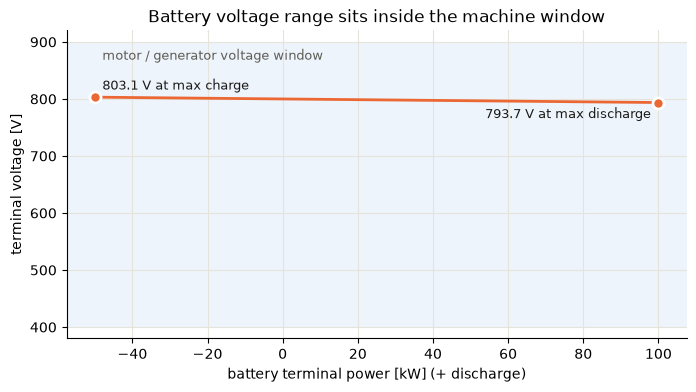

PASS  plot data: polarization line hits both range end points


In [4]:
# Battery polarization line against the motor/generator voltage window.
power_W = np.linspace(-battery.max_charge_power_W, battery.max_discharge_power_W, 300)
# One root covers both quadrants: charging is negative terminal power.
ocv_V, resistance_ohm = battery.voltage_open_circuit_V, battery.resistance_ohm
voltage_V = (ocv_V + np.sqrt(ocv_V**2 - 4 * resistance_ohm * power_W)) / 2
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhspan(Motor().min_voltage_V, Motor().max_voltage_V, color=blue, alpha=0.08, lw=0)
ax.plot(power_W / 1e3, voltage_V, color=orange, lw=2)
ax.plot([-battery.max_charge_power_W / 1e3, battery.max_discharge_power_W / 1e3], [max_voltage_V, min_voltage_V],
        "o", color=orange, ms=8, mec="white", mew=2)
ax.text(-48, Motor().max_voltage_V - 12, "motor / generator voltage window", color=ink_muted, fontsize=9, va="top")
ax.text(battery.max_discharge_power_W / 1e3 - 2, min_voltage_V - 8, f"{min_voltage_V:.1f} V at max discharge",
        ha="right", va="top", fontsize=9, color=ink)
ax.text(-battery.max_charge_power_W / 1e3 + 2, max_voltage_V + 8, f"{max_voltage_V:.1f} V at max charge",
        ha="left", va="bottom", fontsize=9, color=ink)
ax.set(xlabel="battery terminal power [kW] (+ discharge)", ylabel="terminal voltage [V]", ylim=(380, 920),
       title="Battery voltage range sits inside the machine window")
plt.show()
check("plot data: polarization line hits both range end points",
      close(voltage_V[0], max_voltage_V, rel=1e-9) and close(voltage_V[-1], min_voltage_V, rel=1e-9))

## 3. Operating margins at the reference point

The topology example now constrains every operating margin to be $\ge 0$
instead of listing ratings by hand. Its solved margins show where headroom is
smallest: motor shaft power, because the rotor's 89.3 kW is delivered through
a 97 %-efficient gearbox from a 100 kW motor.

In [5]:
opti = asb.Opti()
problem = build_point_problem(opti)
opti.subject_to(problem.rotor.thrust_N == 5000)
solution = opti.solve(verbose=False)
report = margin_report(problem.margins, solution.value)
for entry in report:
    print(f"{entry.label:<28}{float(entry.value):+8.4f}")

check("operating: all margins non-negative at the reference point", all(e.compatible for e in report))
check("operating: motor shaft power is most critical", report[0].label == "motor power_shaft_W")
shaft_power_W = float(solution.value(problem.rotor.shaft_power_W))
check("operating: motor margin = 1 - P_rotor / (eta_gear * P_rated)",
      close(float(report[0].value), 1 - shaft_power_W / 0.97 / 100000, rel=1e-6))
check("operating: 15 margins (5 motor, 5 generator, 2 battery, 1 each for engine, gearbox, rotor)",
      len(problem.margins) == 15)

motor power_shaft_W          +0.0795
gearbox power_input_W        +0.0795
propulsor power_shaft_W      +0.1071
generator max_voltage_V      +0.1124
motor max_voltage_V          +0.1124
generator power_shaft_W      +0.1993
turboshaft power_shaft_W     +0.4662
motor torque_Nm              +0.5398
generator torque_Nm          +0.5996
generator speed_rad_s        +0.6000
motor speed_rad_s            +0.6000
battery discharge_power_W    +0.8082
generator min_voltage_V      +0.9970
motor min_voltage_V          +0.9970
battery charge_power_W       +1.3837
PASS  operating: all margins non-negative at the reference point
PASS  operating: motor shaft power is most critical
PASS  operating: motor margin = 1 - P_rotor / (eta_gear * P_rated)
PASS  operating: 15 margins (5 motor, 5 generator, 2 battery, 1 each for engine, gearbox, rotor)


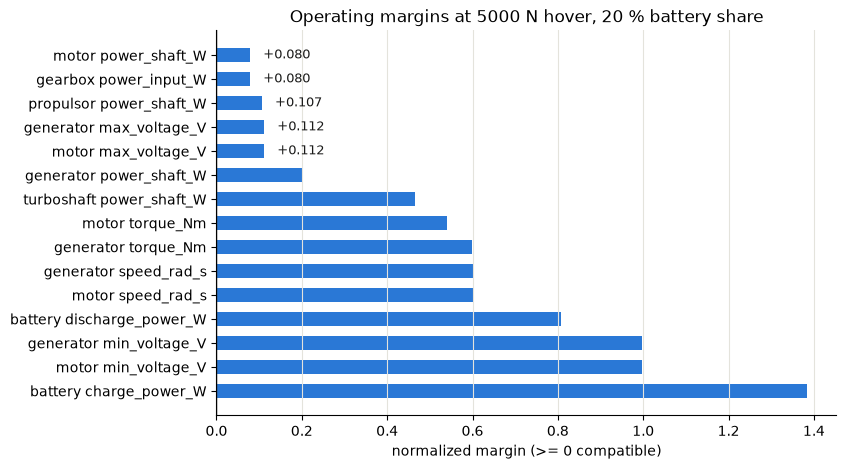

In [6]:
labels = [e.label for e in report][::-1]
values = [float(e.value) for e in report][::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, values, color=[critical if v < 0 else blue for v in values], height=0.6)
ax.axvline(0, color=ink, lw=1)
for y, v in enumerate(values):
    if v < 0.15:
        ax.text(v + 0.03, y, f"{v:+.3f}", va="center", fontsize=9, color=ink)
ax.set(xlabel="normalized margin (>= 0 compatible)", title="Operating margins at 5000 N hover, 20 % battery share")
ax.grid(axis="y", visible=False)
plt.show()

## 4. Design margins of the default series hybrid

Design margins use ratings only. Across a shaft, the downstream port must tolerate
the upstream maximum: `margin_below(upstream max, downstream max)`. On the bus the
battery's voltage range must sit inside each machine's window and loss-free
supply must cover demand (with instance counts).

The default parts are deliberately not matched: the 150 kW turboshaft can overdrive
the 100 kW generator. The report records this as $-0.5$ and leaves the components
unchanged.

In [7]:
default_hybrid = default_series_hybrid()
before = {name: dataclasses.asdict(i.component) for name, i in default_hybrid.instances.items()}
design = margin_report(design_margins(default_hybrid))
for entry in design:
    print(f"{entry.label:<62}{entry.value:+8.4f}")
after = {name: dataclasses.asdict(i.component) for name, i in default_hybrid.instances.items()}

design_values = {e.label: e.value for e in design}
check("design: turboshaft 150 kW vs generator 100 kW gives -0.5",
      close(design_values["turboshaft.shaft->generator.shaft max_power_W"], -0.5))
check("design: motor 100 kW into gearbox 100 kW gives 0",
      close(design_values["motor.shaft->gearbox.shaft_in max_power_W"], 0.0))
check("design: gearbox 97 kW output into 100 kW rotor gives +0.03",
      close(design_values["gearbox.shaft_out->propulsor.shaft max_power_W"], 0.03))
check("design: loss-free bus supply 200 kW vs demand 100 kW gives +1",
      close(design_values["bus power_W (loss-free)"], 1.0))
check("design: battery range inside both machine windows",
      all(v >= 0 for k, v in design_values.items() if "voltage" in k))
check("design: no speed/torque margin where only one side declares it",
      not any("speed" in k or "torque" in k for k in design_values))
check("design: margins never modify components", before == after)

four = {m.label: m.value for m in design_margins(default_series_hybrid(count_rotors=4))}
check("design: four rotor strings double-overload the bus ((200 - 400) / 400)",
      close(four["bus power_W (loss-free)"], -0.5))
low_voltage = {m.label: m.value for m in design_margins(
    default_series_hybrid(battery=Battery(voltage_open_circuit_V=410.0)))}
print(f"\n410 V pack min-voltage margin vs motor: "
      f"{low_voltage['bus battery.electrical->motor.electrical min_voltage_V']:+.4f}")
check("design: a 410 V pack sags below the 400 V motor minimum at max discharge",
      low_voltage["bus battery.electrical->motor.electrical min_voltage_V"] < 0)

turboshaft.shaft->generator.shaft max_power_W                  -0.5000
motor.shaft->gearbox.shaft_in max_power_W                      +0.0000
gearbox.shaft_out->propulsor.shaft max_power_W                 +0.0300
bus battery.electrical->generator.electrical max_voltage_V     +0.1077
bus battery.electrical->motor.electrical max_voltage_V         +0.1077
bus battery.electrical->generator.electrical min_voltage_V     +0.9843
bus battery.electrical->motor.electrical min_voltage_V         +0.9843
bus power_W (loss-free)                                        +1.0000
PASS  design: turboshaft 150 kW vs generator 100 kW gives -0.5
PASS  design: motor 100 kW into gearbox 100 kW gives 0
PASS  design: gearbox 97 kW output into 100 kW rotor gives +0.03
PASS  design: loss-free bus supply 200 kW vs demand 100 kW gives +1
PASS  design: battery range inside both machine windows
PASS  design: no speed/torque margin where only one side declares it
PASS  design: margins never modify components
PASS  desi

## 5. Reference case 1: margins reproduce the Tier 2 point

Replacing the hand-written rating list with operating margins must not move the
solution: at 5000 N the ratings are inactive, so the point equals the Tier 1
explicit coupling and the Tier 2 topology result.

In [8]:
explicit = solve_reference_point()
single = solve_topology_point(count_rotors=1)
for field in ("thrust_N", "shaft_power_W", "battery_power_W", "fuel_flow_kg_s"):
    a, b = getattr(explicit, field), getattr(single, field)
    print(f"{field:<18}{a:>16.8g}{b:>16.8g}")
    check(f"reference 1: {field} unchanged within 1e-6", close(b, a, rel=1e-6))
check("reference 1: minimum operating margin positive", single.min_operating_margin > 0)
check("reference 1: binding margin reported", single.binding_margin_label == "motor power_shaft_W")

thrust_N                      5000            5000
PASS  reference 1: thrust_N unchanged within 1e-6
shaft_power_W            89285.745       89285.745
PASS  reference 1: shaft_power_W unchanged within 1e-6
battery_power_W          19184.051       19184.051
PASS  reference 1: battery_power_W unchanged within 1e-6
fuel_flow_kg_s        0.0062071753    0.0062071753
PASS  reference 1: fuel_flow_kg_s unchanged within 1e-6
PASS  reference 1: minimum operating margin positive
PASS  reference 1: binding margin reported


## 6. Reference case 3: maximum thrust and the binding margin

Maximizing thrust per rotor at 20 % battery share with every operating margin
$\ge 0$ shows which hardware limit sets capability. Sweeping the motor rating moves
the limit: below 100 kW the motor binds; above it the 100 kW gearbox input rating
caps thrust and a larger motor buys nothing. The margin report names the limit
without resizing anything.

motor     50 kW   max thrust  3328.7 N   binding motor power_shaft_W
motor     70 kW   max thrust  4165.8 N   binding motor power_shaft_W
motor     90 kW   max thrust  4925.6 N   binding motor power_shaft_W
motor    110 kW   max thrust  5284.0 N   binding gearbox power_input_W
motor    130 kW   max thrust  5284.0 N   binding gearbox power_input_W
motor    150 kW   max thrust  5284.0 N   binding gearbox power_input_W
PASS  reference 3: every max-thrust solution has a zero (binding) margin
PASS  reference 3: no max-thrust solution violates a margin
PASS  reference 3: motor binds below 100 kW
PASS  reference 3: gearbox binds above 100 kW
PASS  reference 3: max thrust rises with motor rating, then plateaus


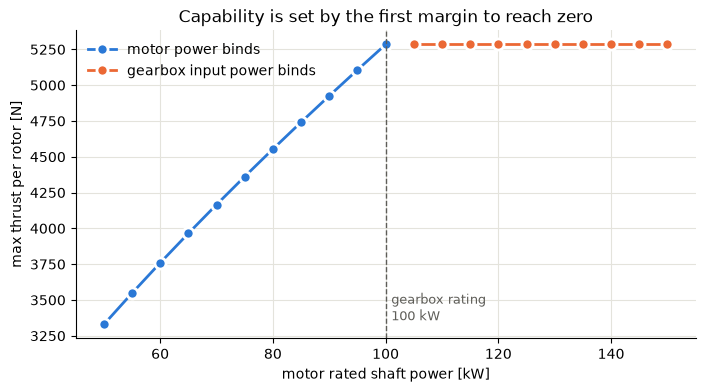

In [9]:
def max_thrust(power_rated_motor_W):
    opti = asb.Opti()
    problem = build_point_problem(opti, motor=Motor(power_rated_W=power_rated_motor_W))
    opti.minimize(-problem.rotor.thrust_N / 5000)
    solution = opti.solve(verbose=False)
    report = margin_report(problem.margins, solution.value)
    return float(solution.value(problem.rotor.thrust_N)), report


ratings_W = np.linspace(50e3, 150e3, 21)
results = [max_thrust(p) for p in ratings_W]
thrust_max_N = np.array([r[0] for r in results])
# At exactly 100 kW motor and gearbox bind together; checks skip that tie.
binding = [r[1][0].label for r in results]
for p, t, b in zip(ratings_W[::4], thrust_max_N[::4], binding[::4]):
    print(f"motor {p / 1e3:6.0f} kW   max thrust {t:7.1f} N   binding {b}")

check("reference 3: every max-thrust solution has a zero (binding) margin",
      all(abs(float(r[1][0].value)) < 1e-6 for r in results))
check("reference 3: no max-thrust solution violates a margin",
      all(float(r[1][0].value) > -1e-6 for r in results))
check("reference 3: motor binds below 100 kW", all(b == "motor power_shaft_W" for p, b in zip(ratings_W, binding) if p < 99e3))
check("reference 3: gearbox binds above 100 kW",
      all(b == "gearbox power_input_W" for p, b in zip(ratings_W, binding) if p > 101e3))
check("reference 3: max thrust rises with motor rating, then plateaus",
      np.all(np.diff(thrust_max_N[ratings_W < 99e3]) > 0) and np.ptp(thrust_max_N[ratings_W > 101e3]) < 1e-3)

fig, ax = plt.subplots(figsize=(8, 4))
motor_limited = ratings_W <= 100e3
ax.plot(ratings_W[motor_limited] / 1e3, thrust_max_N[motor_limited], color=blue, lw=2, marker="o", ms=8,
        mec="white", mew=2, label="motor power binds")
ax.plot(ratings_W[~motor_limited] / 1e3, thrust_max_N[~motor_limited], color=orange, lw=2, marker="o", ms=8,
        mec="white", mew=2, label="gearbox input power binds")
ax.axvline(100, color=ink_muted, lw=1, ls="--")
ax.text(101, thrust_max_N.min(), "gearbox rating\n100 kW", color=ink_muted, fontsize=9, va="bottom")
ax.set(xlabel="motor rated shaft power [kW]", ylabel="max thrust per rotor [N]",
       title="Capability is set by the first margin to reach zero")
ax.legend(frameon=False, loc="upper left")
plt.show()

## 7. Reference case 4: sizing a rating with design margins

Because design margins are functions of component parameters, an optimizer can
use them directly. Minimizing the generator rating subject to every design margin
$\ge 0$ returns the smallest generator the 150 kW turboshaft cannot overdrive. The
margin code never resizes anything; the caller's Opti does.

In [10]:
opti = asb.Opti()
power_rated_generator_W = opti.variable(init_guess=100000, lower_bound=1)
sized = default_series_hybrid(generator=Generator(power_rated_W=power_rated_generator_W))
margins = design_margins(sized)
check("symbolic: design margins with a symbolic rating are CasADi MX",
      any(isinstance(m.value, cas.MX) for m in margins))
opti.minimize(power_rated_generator_W / 1e5)
opti.subject_to([m.value >= 0 for m in margins])
solution = opti.solve(verbose=False)
print(f"minimum generator rating = {solution.value(power_rated_generator_W) / 1e3:.3f} kW")
check("reference 4: minimum generator rating equals turboshaft rating (150 kW)",
      close(float(solution.value(power_rated_generator_W)), 150000, rel=1e-6))
check("reference 4: all design margins satisfied at the optimum",
      all(float(solution.value(m.value)) > -1e-8 for m in margins))

PASS  symbolic: design margins with a symbolic rating are CasADi MX
minimum generator rating = 150.000 kW
PASS  reference 4: minimum generator rating equals turboshaft rating (150 kW)
PASS  reference 4: all design margins satisfied at the optimum


## 8. Architectural boundaries

Margin code builds expressions only: `core/margins.py` and
`powertrain/compatibility.py` reference no Opti API, and `core/margins.py`
imports nothing from higher layers.

In [11]:
package = repo_root / "src/aircraft_closure"
optimization_names = {"Opti", "variable", "subject_to", "solve", "minimize", "parameter"}
for rel in ("core/margins.py", "powertrain/compatibility.py"):
    tree = ast.parse((package / rel).read_text(encoding="utf-8"))
    used = {n.id for n in ast.walk(tree) if isinstance(n, ast.Name)}
    used |= {n.attr for n in ast.walk(tree) if isinstance(n, ast.Attribute)}
    check(f"boundaries: {rel} references no Opti API", not used & optimization_names)
margins_tree = ast.parse((package / "core/margins.py").read_text(encoding="utf-8"))
margins_imports = {n.module for n in ast.walk(margins_tree) if isinstance(n, ast.ImportFrom)}
margins_imports |= {a.name for n in ast.walk(margins_tree) if isinstance(n, ast.Import) for a in n.names}
check("boundaries: core/margins.py imports no powertrain code",
      not any("powertrain" in (m or "") for m in margins_imports))

PASS  boundaries: core/margins.py references no Opti API
PASS  boundaries: powertrain/compatibility.py references no Opti API
PASS  boundaries: core/margins.py imports no powertrain code


## 9. Summary and unit test suite

In [12]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

47 / 47 notebook checks passed


In [13]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 201 tests in 5.044s

OK
